# Random Forest Classifier - Fruit Classification
**Dataset:** Fruits dataset (300 samples, 4 features)

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## Importing (Reading) Datasets

In [2]:
df = pd.read_csv('fruits.csv')
print(df.head())
print(df.info())


   Weight  Size  Sweetness  Acidity   Fruit
0   196.6   8.5       11.4      6.5  Orange
1   160.0   9.8       16.0      3.4   Mango
2   152.1  11.9       19.0      3.6   Mango
3   142.8   7.6       11.1      7.3  Orange
4   156.2   7.6       10.3      6.9   Apple
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Weight     300 non-null    float64
 1   Size       300 non-null    float64
 2   Sweetness  300 non-null    float64
 3   Acidity    300 non-null    float64
 4   Fruit      300 non-null    str    
dtypes: float64(4), str(1)
memory usage: 11.8 KB
None


## Exploratory Data Analysis

In [3]:
df.describe()


,Weight,Size,Sweetness,Acidity
count,300.00000,300.000000,300.000000,300.000000
mean,116.07800,5.860333,16.855000,4.522667
std,73.82316,3.347049,4.355446,1.738398
min,3.00000,1.000000,9.000000,2.000000
25%,5.97500,2.000000,13.600000,3.200000
50%,136.80000,7.100000,16.550000,4.100000
75%,168.82500,8.400000,19.600000,5.800000
max,248.10000,12.000000,26.900000,8.800000


In [4]:
df.isnull().sum()


Weight       0
Size         0
Sweetness    0
Acidity      0
Fruit        0
dtype: int64

## Encoding Categorical Variables

In [5]:
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])
df.head()


,Weight,Size,Sweetness,Acidity,Fruit
0,196.6,8.5,11.4,6.5,Orange
1,160.0,9.8,16.0,3.4,Mango
2,152.1,11.9,19.0,3.6,Mango
3,142.8,7.6,11.1,7.3,Orange
4,156.2,7.6,10.3,6.9,Apple


## Splitting into Features and Target

In [6]:
X = df.drop('Fruit', axis=1)
y = df['Fruit']


## Splitting Dataset into Training and Testing Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Fitting the Model - Random Forest Classifier

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## Predictions

In [9]:
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
print(results)


     Weight  Size  Sweetness  Acidity  Actual Predicted
203     5.1   1.4       16.2      3.6   Grape     Grape
266   111.4   4.3       20.6      4.5  Banana    Banana
152   212.4  10.2       16.6      4.7   Mango     Mango
9     151.8   8.0       11.2      6.6  Orange    Orange
233   156.1   7.5       11.9      7.5  Orange    Orange
226   105.4   3.1       26.7      4.5  Banana    Banana
196     5.5   1.4       18.9      2.8   Grape     Grape
109   186.9   9.0       13.0      7.7  Orange    Orange
5     188.2  11.9       16.8      5.6   Mango     Mango
175   171.0  11.6       15.2      3.6   Mango     Mango
237   189.5   8.7       11.8      8.5  Orange    Orange
57    192.1   7.1       11.3      7.3  Orange    Orange
218     4.4   1.6       16.4      2.8   Grape     Grape
45    157.1   7.8       13.8      4.8   Apple     Apple
182     3.5   1.7       16.2      2.2   Grape     Grape
221   143.9   8.4       10.3      4.3   Apple     Apple
289   108.0   4.0       21.0      3.3  Banana   

## Evaluation Metrics

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))


Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0  0  1]
 [ 0 11  0  0  0]
 [ 0  0 18  0  0]
 [ 1  0  0 10  0]
 [ 0  0  0  0  9]]


## Confusion Matrix Visualization

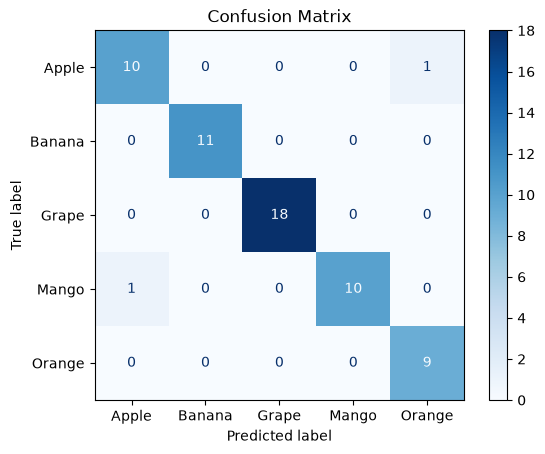

In [11]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
